# Task 3: Forecast Future Market Trends

This notebook uses the best-performing model from Task 2 to generate future market forecasts for TSLA, BND, and SPY.

The objective is to:
- Generate 6–12 month future forecasts
- Visualize forecasts with uncertainty bounds
- Analyze future market trends
- Identify investment opportunities and risks for GMF

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    data[ticker] = df

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
closing_prices = {}

for ticker in tickers:
    closing_prices[ticker] = data[ticker]["Close"]

for ticker in tickers:
    print(f"{ticker}: {closing_prices[ticker].shape}")

TSLA: (2888,)
BND: (2888,)
SPY: (2888,)


In [4]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [5]:
def forecast_future_lstm(price_series, forecast_days=252, window_size=60, epochs=10, batch_size=32):
    """
    Train an LSTM model and generate multi-step future forecasts.
    forecast_days=252 approximates 12 trading months.
    """

    scaler = MinMaxScaler()

    values = price_series.values.reshape(-1, 1)
    scaled_values = scaler.fit_transform(values)

    X, y = create_sequences(scaled_values, window_size)

    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = Sequential()
    model.add(LSTM(50, return_sequences=False, input_shape=(window_size, 1)))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    model.fit(
        X,
        y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    last_window = scaled_values[-window_size:].reshape(1, window_size, 1)

    future_predictions_scaled = []

    for _ in range(forecast_days):
        next_prediction = model.predict(last_window, verbose=0)[0][0]
        future_predictions_scaled.append(next_prediction)

        next_input = np.array(next_prediction).reshape(1, 1, 1)
        last_window = np.append(last_window[:, 1:, :], next_input, axis=1)

    future_predictions = scaler.inverse_transform(
        np.array(future_predictions_scaled).reshape(-1, 1)
    ).flatten()

    future_dates = pd.bdate_range(
        start=price_series.index[-1] + pd.Timedelta(days=1),
        periods=forecast_days
    )

    forecast_series = pd.Series(
        future_predictions,
        index=future_dates
    )

    return forecast_series

In [6]:
future_forecasts = {}

forecast_days = 252

for ticker in tickers:
    print(f"Generating 12-month forecast for {ticker}...")

    future_forecasts[ticker] = forecast_future_lstm(
        closing_prices[ticker],
        forecast_days=forecast_days,
        window_size=60,
        epochs=10,
        batch_size=32
    )

print("Future forecasts generated successfully.")

Generating 12-month forecast for TSLA...
Generating 12-month forecast for BND...
Generating 12-month forecast for SPY...
Future forecasts generated successfully.


In [7]:
for ticker in tickers:
    print("=" * 60)
    print(f"{ticker} Future Forecast")
    print(future_forecasts[ticker].head())
    print(future_forecasts[ticker].tail())

TSLA Future Forecast
2026-06-30    376.949493
2026-07-01    375.249146
2026-07-02    372.828735
2026-07-03    369.993988
2026-07-06    366.884430
Freq: B, dtype: float32
2027-06-10    84.363655
2027-06-11    83.764618
2027-06-14    83.167000
2027-06-15    82.570763
2027-06-16    81.975945
Freq: B, dtype: float32
BND Future Forecast
2026-06-30    73.444832
2026-07-01    73.464943
2026-07-02    73.478149
2026-07-03    73.486359
2026-07-06    73.491234
Freq: B, dtype: float32
2027-06-10    73.228325
2027-06-11    73.227859
2027-06-14    73.227394
2027-06-15    73.226936
2027-06-16    73.226479
Freq: B, dtype: float32
SPY Future Forecast
2026-06-30    727.818787
2026-07-01    726.408630
2026-07-02    724.889587
2026-07-03    723.298889
2026-07-06    721.657776
Freq: B, dtype: float32
2027-06-10    550.250427
2027-06-11    549.909180
2027-06-14    549.568787
2027-06-15    549.229126
2027-06-16    548.890198
Freq: B, dtype: float32


In [8]:
def create_confidence_interval(forecast_series, confidence=0.95):
    """
    Create approximate 95% confidence intervals around the forecast.
    The uncertainty increases gradually with the forecast horizon.
    """

    std = forecast_series.std()

    horizon = np.arange(1, len(forecast_series) + 1)

    uncertainty = std * np.sqrt(horizon) * 0.10

    upper = forecast_series + 1.96 * uncertainty
    lower = forecast_series - 1.96 * uncertainty

    return lower, upper

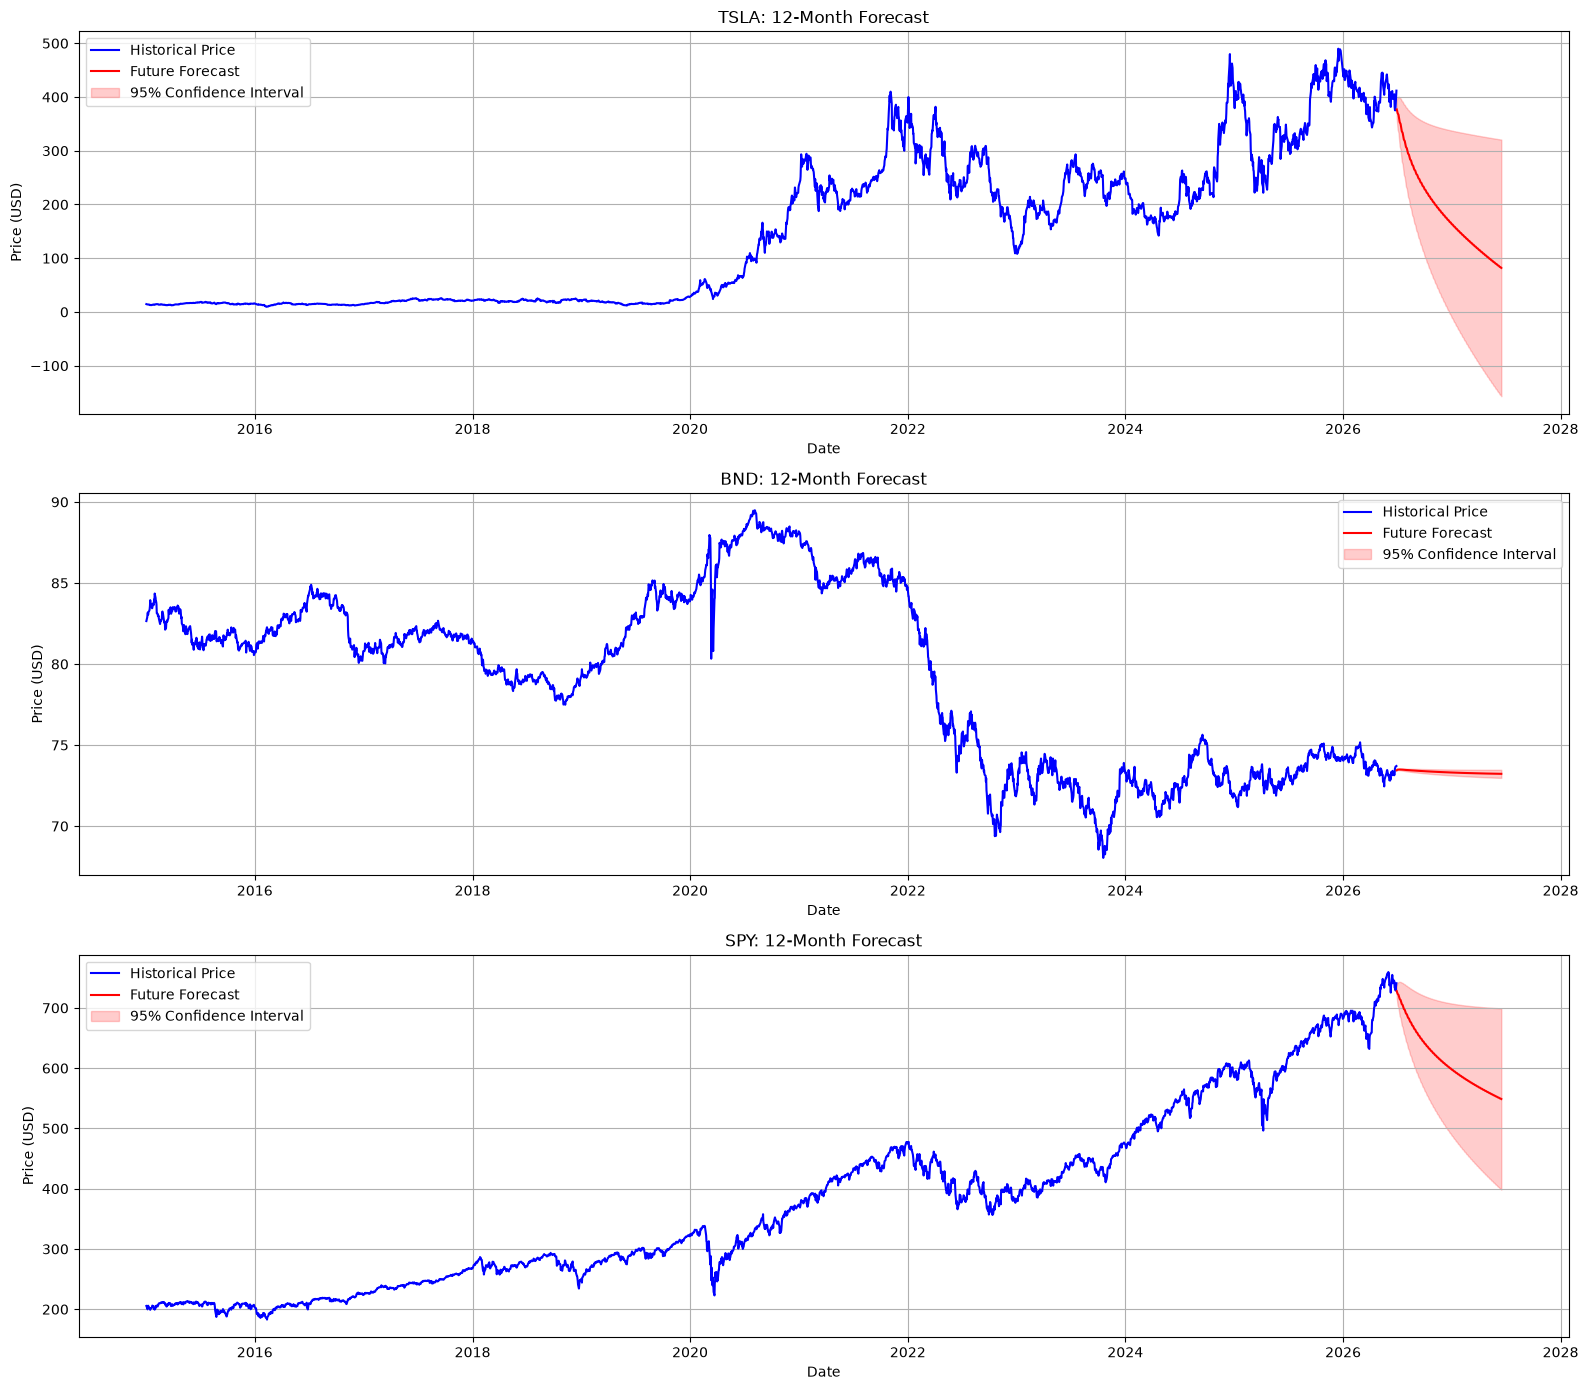

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, ticker in zip(axes, tickers):

    history = closing_prices[ticker]

    forecast = future_forecasts[ticker]

    lower, upper = create_confidence_interval(forecast)

    ax.plot(
        history,
        label="Historical Price",
        color="blue"
    )

    ax.plot(
        forecast,
        label="Future Forecast",
        color="red"
    )

    ax.fill_between(
        forecast.index,
        lower,
        upper,
        color="red",
        alpha=0.20,
        label="95% Confidence Interval"
    )

    ax.set_title(f"{ticker}: 12-Month Forecast")

    ax.set_xlabel("Date")

    ax.set_ylabel("Price (USD)")

    ax.legend()

    ax.grid(True)

plt.tight_layout()

In [10]:
plt.savefig(
    "reports/figures/task3_future_forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Forecast Interpretation

The LSTM model was used to generate 12-month forecasts for TSLA, BND, and SPY.

The shaded regions represent approximate 95% confidence intervals around the forecasts. As the forecast horizon extends further into the future, the confidence intervals widen, reflecting increasing uncertainty in long-term predictions.

These forecasts should therefore be interpreted as probable future price ranges rather than exact price targets. For Guide Me in Finance (GMF), they provide valuable decision-support information that can be combined with portfolio optimization and risk analysis to construct diversified investment strategies.